In [1]:
from monai.networks.nets import UNet
from monai.networks.layers import Norm
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


2025-11-22 10:06:12.557169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763802372.600630    4743 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763802372.614107    4743 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763802372.677113    4743 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763802372.677136    4743 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763802372.677138    4743 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

cuda


In [2]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH
).to(device)

print(model)

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential(


In [3]:
from monai.losses import DiceLoss

# For binary segmentation with sigmoid output
loss = DiceLoss(sigmoid=True, to_onehot_y=False)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
import glob
from pathlib import Path
from monai.data import Dataset, DataLoader
from monai.data.image_reader import NibabelReader

try:
    import nibabel  # ensure dependency available
except ImportError as exc:
    raise ImportError("nibabel is required for loading NIfTI files. Install via `pip install nibabel`." ) from exc
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    Orientationd,
    ScaleIntensityRanged,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandRotate90d,
    RandFlipd,
    RandShiftIntensityd,
    ToTensord,
)
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
import numpy as np
from tqdm import tqdm

# Initialize NIfTI reader
nibabel_reader = NibabelReader()

# Data directory
data_dir = Path("data/ATLAS_2/Training")

# Find all image and mask pairs
image_files = sorted(glob.glob(str(data_dir / "**/*_T1w.nii.gz"), recursive=True))
mask_files = sorted(glob.glob(str(data_dir / "**/*_label-L_desc-T1lesion_mask.nii.gz"), recursive=True))

print(f"Found {len(image_files)} image files")
print(f"Found {len(mask_files)} mask files")

# Create data dictionary
data_dicts = [
    {"image": img, "label": mask}
    for img, mask in zip(image_files, mask_files)
]

# Split into train and validation (80/20)
np.random.seed(42)
np.random.shuffle(data_dicts)
split_idx = int(len(data_dicts) * 0.8)
train_files = data_dicts[:split_idx]
val_files = data_dicts[split_idx:]

print(f"Training samples: {len(train_files)}")
print(f"Validation samples: {len(val_files)}")


Found 655 image files
Found 655 mask files
Training samples: 524
Validation samples: 131


In [5]:
# Define transforms for training
train_transforms = Compose([
    LoadImaged(keys=["image", "label"], reader=nibabel_reader, image_only=False),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1,
        neg=1,
        num_samples=1,
        image_key="image",
        image_threshold=0,
    ),
    RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=(0, 1)),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
    ToTensord(keys=["image", "label"]),
])

# Define transforms for validation
val_transforms = Compose([
    LoadImaged(keys=["image", "label"], reader=nibabel_reader, image_only=False),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    ToTensord(keys=["image", "label"]),
])

# Create datasets
train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds = Dataset(data=val_files, transform=val_transforms)

# Create data loaders
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)

print("Data loaders created successfully!")


Data loaders created successfully!


/home/stachu/projects/ood-detection/.venv/lib/python3.13/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [7]:
def train_model(model, optimizer, loss_fn, train_loader, val_loader, num_epochs, 
                val_interval=5, model_save_path="best_metric_model.pth",
                starting_epoch=0, best_metric=-1, best_metric_epoch=-1,
                epoch_loss_values=None, metric_values=None):
    """
    Training function for the model.
    
    Args:
        model: The model to train
        optimizer: The optimizer
        loss_fn: The loss function
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Number of epochs to train
        val_interval: Validation interval (every N epochs)
        model_save_path: Path to save the best model
        starting_epoch: Starting epoch number (for continuing training)
        best_metric: Best metric value so far (for continuing training)
        best_metric_epoch: Best metric epoch so far (for continuing training)
        epoch_loss_values: List of epoch loss values (for continuing training)
        metric_values: List of metric values (for continuing training)
    
    Returns:
        Dictionary with training history: epoch_loss_values, metric_values, 
        best_metric, best_metric_epoch
    """
    if epoch_loss_values is None:
        epoch_loss_values = []
    if metric_values is None:
        metric_values = []
    
    # Dice metric for evaluation
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    
    print(f"Starting training for {num_epochs} epochs...")
    print(f"Starting from epoch {starting_epoch + 1}")
    
    for epoch in range(num_epochs):
        print("-" * 10)
        current_epoch = starting_epoch + epoch + 1
        print(f"epoch {current_epoch}/{starting_epoch + num_epochs}")
        model.train()
        epoch_loss = 0
        step = 0
        
        for batch_data in tqdm(train_loader, desc=f"Epoch {current_epoch}"):
            step += 1
            inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(inputs)
            
            # Calculate loss (DiceLoss with sigmoid=True applies sigmoid internally)
            loss_value = loss_fn(outputs, labels.float())
            
            # Backward pass
            loss_value.backward()
            optimizer.step()
            epoch_loss += loss_value.item()
        
        epoch_loss /= step
        epoch_loss_values.append(epoch_loss)
        print(f"epoch {current_epoch} average loss: {epoch_loss:.4f}")
        
        # Validation
        if current_epoch % val_interval == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                    
                    # Use sliding window inference for full volume prediction
                    val_outputs = sliding_window_inference(
                        val_inputs, (96, 96, 96), 4, model, overlap=0.5
                    )
                    
                    # Convert outputs to binary predictions
                    val_outputs = torch.sigmoid(val_outputs) > 0.5
                    
                    dice_metric(y_pred=val_outputs.float(), y=val_labels.float())
                
                metric = dice_metric.aggregate().item()
                dice_metric.reset()
                metric_values.append((current_epoch, metric))
                
                if metric > best_metric:
                    best_metric = metric
                    best_metric_epoch = current_epoch
                    torch.save(model.state_dict(), model_save_path)
                    print("saved new best metric model")
                
                print(
                    f"current epoch: {current_epoch} current mean dice: {metric:.4f}"
                    f"\nbest mean dice: {best_metric:.4f} at epoch: {best_metric_epoch}"
                )
    
    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
    
    return {
        'epoch_loss_values': epoch_loss_values,
        'metric_values': metric_values,
        'best_metric': best_metric,
        'best_metric_epoch': best_metric_epoch
    }



In [ ]:
# Training parameters
num_epochs = 50
val_interval = 5
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

# Train the model
training_history = train_model(
    model=model,
    optimizer=optimizer,
    loss_fn=loss,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    val_interval=val_interval
)

# Update variables from training history
epoch_loss_values = training_history['epoch_loss_values']
metric_values = training_history['metric_values']
best_metric = training_history['best_metric']
best_metric_epoch = training_history['best_metric_epoch']

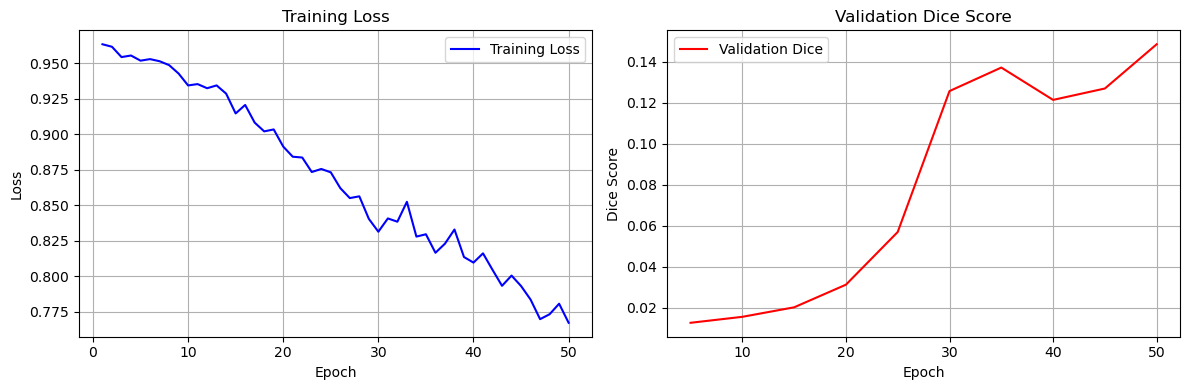

In [ ]:
import matplotlib.pyplot as plt

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(epoch_loss_values) + 1), epoch_loss_values, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
# Handle metric_values which may be tuples (epoch, metric) or just metric values
if metric_values and isinstance(metric_values[0], tuple):
    val_epochs = [epoch for epoch, _ in metric_values]
    val_metrics = [metric for _, metric in metric_values]
else:
    val_epochs = [i * val_interval for i in range(1, len(metric_values) + 1)]
    val_metrics = metric_values
plt.plot(val_epochs, val_metrics, 'r-', label='Validation Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.title('Validation Dice Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


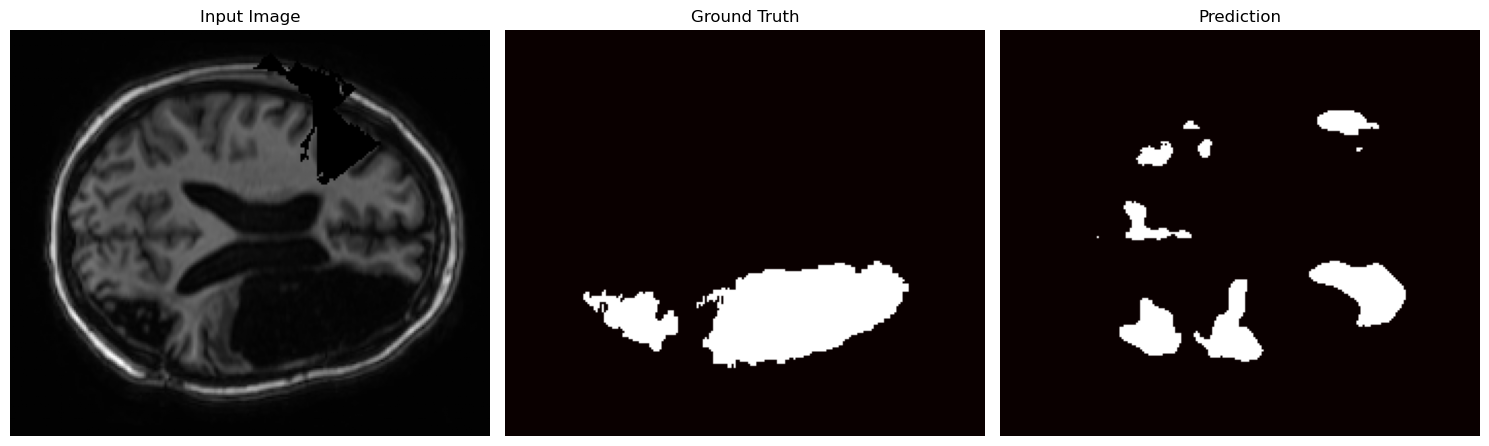

Dice score for this sample: 0.5422


In [8]:
# Load best model and test on a validation sample
model.load_state_dict(torch.load("best_metric_model.pth"))
model.eval()

# Get a sample from validation set
sample = val_files[0]
sample_data = val_transforms(sample)
sample_image = sample_data["image"].unsqueeze(0).to(device)
sample_label = sample_data["label"].unsqueeze(0).to(device)

with torch.no_grad():
    # Predict using sliding window inference
    prediction = sliding_window_inference(
        sample_image, (96, 96, 96), 4, model, overlap=0.5
    )
    prediction = torch.sigmoid(prediction) > 0.5

# Visualize a middle slice
slice_idx = sample_image.shape[-1] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample_image[0, 0, :, :, slice_idx].cpu(), cmap='gray')
axes[0].set_title('Input Image')
axes[0].axis('off')

axes[1].imshow(sample_label[0, 0, :, :, slice_idx].cpu(), cmap='hot')
axes[1].set_title('Ground Truth')
axes[1].axis('off')

axes[2].imshow(prediction[0, 0, :, :, slice_idx].cpu(), cmap='hot')
axes[2].set_title('Prediction')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Calculate Dice score for this sample
dice_metric(y_pred=prediction, y=sample_label)
dice_score = dice_metric.aggregate().item()
dice_metric.reset()
print(f"Dice score for this sample: {dice_score:.4f}")


In [8]:
# Load saved model and continue training for 50 additional epochs
print("Loading saved model...")
model.load_state_dict(torch.load("best_metric_model.pth"))
print(f"Model loaded from best_metric_model.pth (best metric: {best_metric:.4f} at epoch {best_metric_epoch})")

# Continue training for 50 additional epochs
additional_epochs = 50
# Start from the last epoch trained (total epochs so far)
starting_epoch = len(epoch_loss_values) if epoch_loss_values else 0

# Prepare metric_values for continuing training (convert to tuples if needed)
if metric_values and not isinstance(metric_values[0], tuple):
    # Convert existing metric values to tuples
    val_interval_epochs = [i * val_interval for i in range(1, len(metric_values) + 1)]
    metric_values = [(epoch, metric) for epoch, metric in zip(val_interval_epochs, metric_values)]

print(f"\nContinuing training from epoch {starting_epoch + 1} for {additional_epochs} more epochs...")
print(f"Current best metric: {best_metric:.4f} at epoch {best_metric_epoch}")

# Continue training
continued_training_history = train_model(
    model=model,
    optimizer=optimizer,
    loss_fn=loss,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=additional_epochs,
    val_interval=val_interval,
    model_save_path="best_metric_model.pth",
    starting_epoch=starting_epoch,
    best_metric=best_metric,
    best_metric_epoch=best_metric_epoch,
    epoch_loss_values=epoch_loss_values,
    metric_values=metric_values
)

# Update variables from continued training history
epoch_loss_values = continued_training_history['epoch_loss_values']
metric_values = continued_training_history['metric_values']
best_metric = continued_training_history['best_metric']
best_metric_epoch = continued_training_history['best_metric_epoch']

print(f"\nExtended training completed!")
print(f"Final best metric: {best_metric:.4f} at epoch {best_metric_epoch}")
print(f"Total epochs trained: {len(epoch_loss_values)}")


Loading saved model...
Model loaded from best_metric_model.pth (best metric: -1.0000 at epoch -1)

Continuing training from epoch 1 for 50 more epochs...
Current best metric: -1.0000 at epoch -1
Starting training for 50 epochs...
Starting from epoch 1
----------
epoch 1/50


Epoch 1: 100%|██████████| 262/262 [01:12<00:00,  3.60it/s]


epoch 1 average loss: 0.7650
----------
epoch 2/50


Epoch 2: 100%|██████████| 262/262 [01:11<00:00,  3.64it/s]


epoch 2 average loss: 0.7688
----------
epoch 3/50


...

Epoch 49: 100%|██████████| 262/262 [01:12<00:00,  3.62it/s]


epoch 49 average loss: 0.6510
----------
epoch 50/50


Epoch 50: 100%|██████████| 262/262 [01:11<00:00,  3.69it/s]

epoch 50 average loss: 0.6773


current epoch: 50 current mean dice: 0.3673
best mean dice: 0.4215 at epoch: 40
train completed, best_metric: 0.4215 at epoch: 40

Extended training completed!
Final best metric: 0.4215 at epoch 40
Total epochs trained: 50


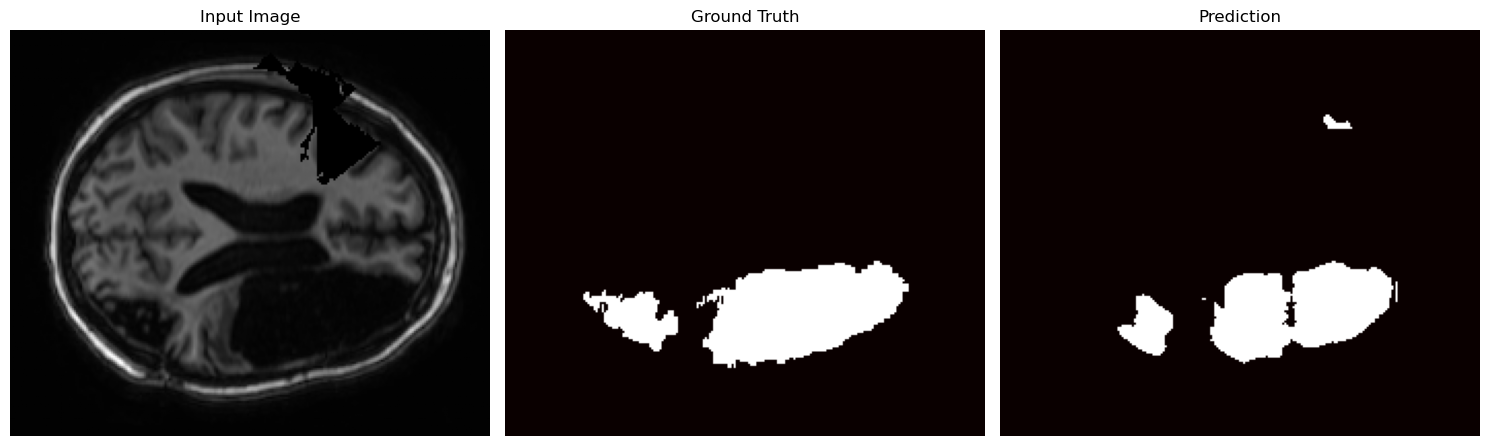

Dice score for this sample: 0.8322


In [12]:
import matplotlib.pyplot as plt
from monai.metrics import DiceMetric

# Load best model and test on a validation sample
model.load_state_dict(torch.load("best_metric_model.pth"))
model.eval()

# Get a sample from validation set
sample = val_files[0]
sample_data = val_transforms(sample)
sample_image = sample_data["image"].unsqueeze(0).to(device)
sample_label = sample_data["label"].unsqueeze(0).to(device)

with torch.no_grad():
    # Predict using sliding window inference
    prediction = sliding_window_inference(
        sample_image, (96, 96, 96), 4, model, overlap=0.5
    )
    prediction = torch.sigmoid(prediction) > 0.5

# Visualize a middle slice
slice_idx = sample_image.shape[-1] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample_image[0, 0, :, :, slice_idx].cpu(), cmap='gray')
axes[0].set_title('Input Image')
axes[0].axis('off')

axes[1].imshow(sample_label[0, 0, :, :, slice_idx].cpu(), cmap='hot')
axes[1].set_title('Ground Truth')
axes[1].axis('off')

axes[2].imshow(prediction[0, 0, :, :, slice_idx].cpu(), cmap='hot')
axes[2].set_title('Prediction')
axes[2].axis('off')

plt.tight_layout()
plt.show()

dice_metric = DiceMetric(include_background=False, reduction="mean")
# Calculate Dice score for this sample
dice_metric(y_pred=prediction, y=sample_label)
dice_score = dice_metric.aggregate().item()
dice_metric.reset()
print(f"Dice score for this sample: {dice_score:.4f}")